In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

datos = {"naranjas": [2, 3, 1, 0], "manzanas": [0, 3, 7, 2]}

compras = pd.DataFrame(datos)
compras

,naranjas,manzanas
0,2,0
1,3,3
2,1,7
3,0,2


In [ ]:
url = "https://raw.githubusercontent.com/ManarOmar/New-York-Airbnb-2019/master/AB_NYC_2019.csv"
data = pd.read_csv(url)
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
print("Dimensiones (filas, columnas):", data.shape)
data.info()
print("¿La columna 'id' es única?:", data["id"].is_unique)
print("Total de registros:", len(data))
print("Hosts (anfitriones) únicos:", data["host_id"].nunique())

Dimensiones (filas, columnas): (48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  in

In [ ]:
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
columnas = [
    "price", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count", "availability_365"
]
data[columnas].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
data.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
sin_resenas = data["number_of_reviews"] == 0
print("Anuncios sin reseñas:", sin_resenas.sum())

print("Faltantes en reviews_per_month:", data["reviews_per_month"].isnull().sum())
print("Faltantes que son exactamente anuncios sin reseñas:",
      (data["reviews_per_month"].isnull() & sin_resenas).sum())

Anuncios sin reseñas: 10052
Faltantes en reviews_per_month: 10052
Faltantes que son exactamente anuncios sin reseñas: 10052


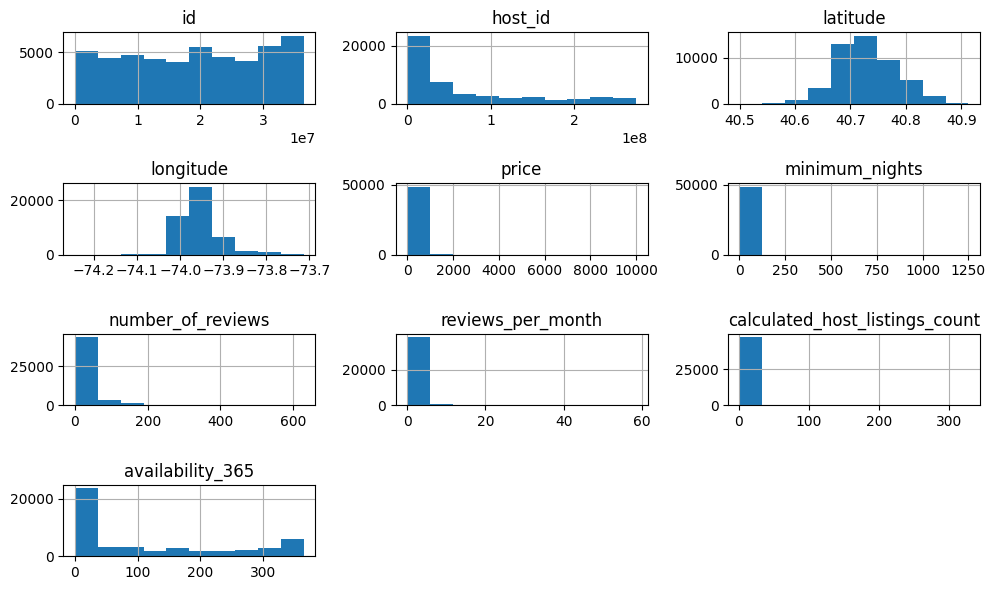

In [ ]:
data.hist(bins=10, figsize=(10, 6))
plt.tight_layout()
plt.show()

In [ ]:
data["neighbourhood"].value_counts()

,count
neighbourhood,
Williamsburg,3920
Bedford-Stuyvesant,3714
Harlem,2658
Bushwick,2465
Upper West Side,1971
...,...
Richmondtown,1
Fort Wadsworth,1
New Dorp,1


In [ ]:
data["room_type"].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


In [ ]:
data["neighbourhood_group"].value_counts()

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


In [ ]:
media = data["reviews_per_month"].mean()
print("Media de reviews_per_month:", round(media, 2))

data["reviews_per_month"] = data["reviews_per_month"].fillna(0)
print("Faltantes restantes en reviews_per_month:", data["reviews_per_month"].isnull().sum())

Media de reviews_per_month: 1.37
Faltantes restantes en reviews_per_month: 0


In [ ]:
numericas = data.select_dtypes(include=np.number)
numericas.columns.tolist()

['id',
 'host_id',
 'latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

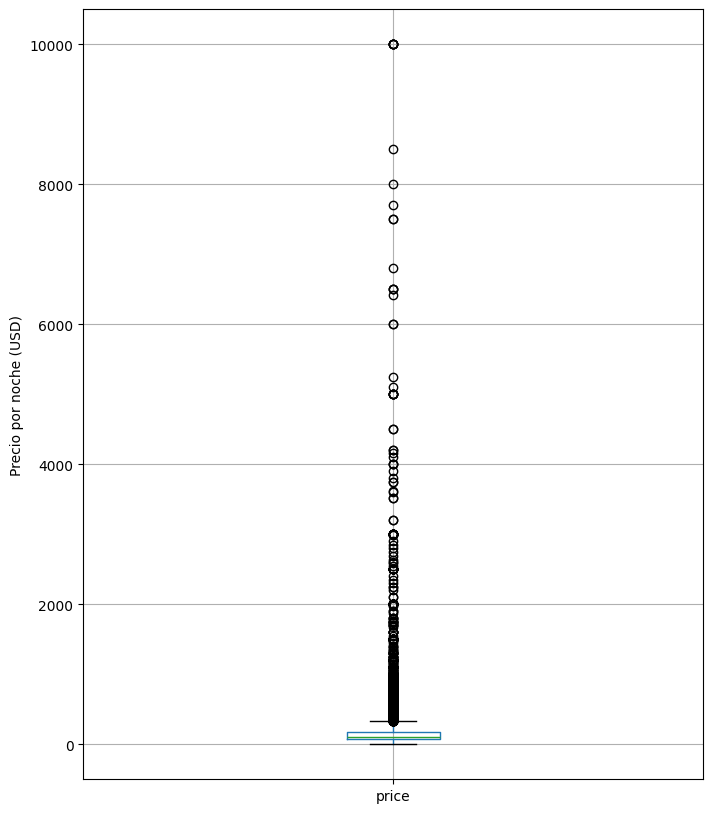

In [ ]:
data.boxplot(column="price", figsize=(8, 10))
plt.ylabel("Precio por noche (USD)")
plt.show()

In [ ]:
precio_minimo = 0
precio_maximo = 500

datos_limpios = data[(data["price"] > precio_minimo) & (data["price"] <= precio_maximo)].copy()

print("Antes:", len(data), "anuncios")
print("Después:", len(datos_limpios), "anuncios")
datos_limpios["price"].describe()

Antes: 48895 anuncios
Después: 47840 anuncios


,price
count,47840.000000
mean,131.560807
std,88.050752
min,10.000000
25%,68.000000
50%,101.000000
75%,172.000000
max,500.000000


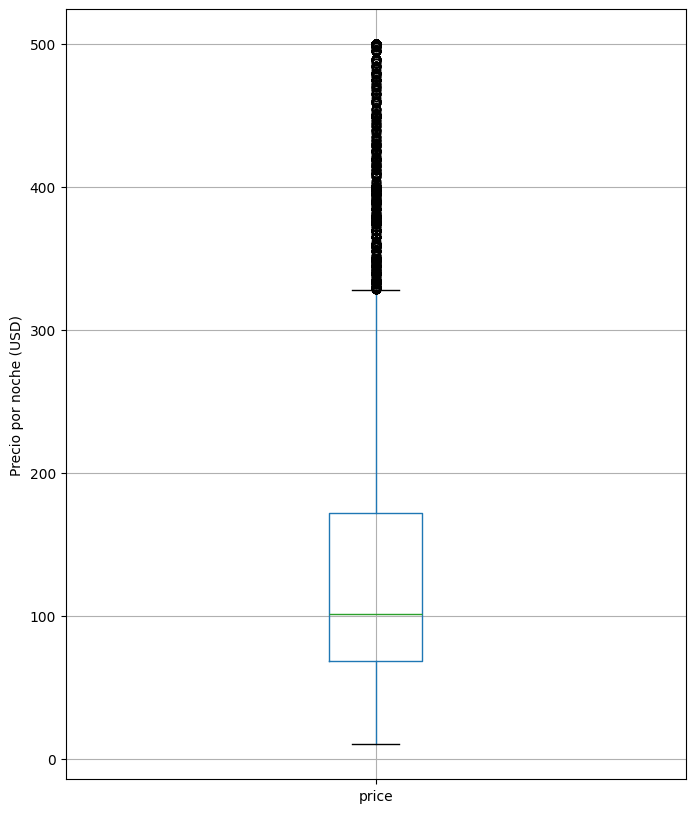

In [ ]:
datos_limpios.boxplot(column="price", figsize=(8, 10))
plt.ylabel("Precio por noche (USD)")
plt.show()

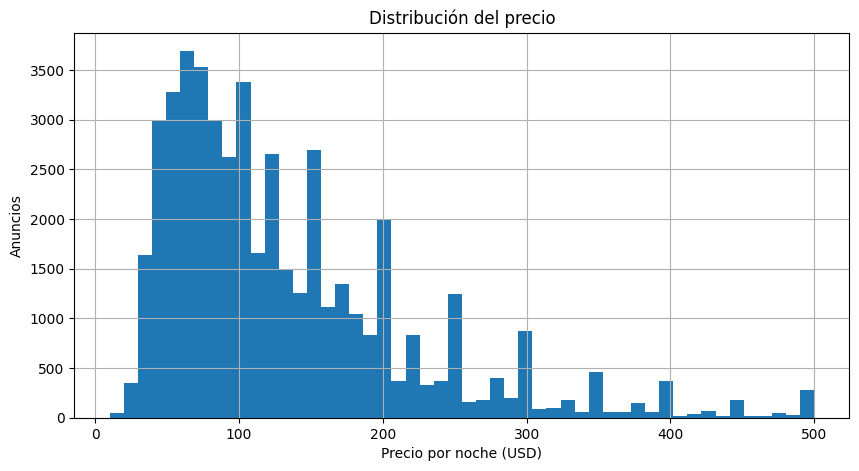

In [ ]:
datos_limpios["price"].hist(bins=50, figsize=(10, 5))
plt.xlabel("Precio por noche (USD)")
plt.ylabel("Anuncios")
plt.title("Distribución del precio")
plt.show()

In [ ]:
corte_economico = 80
corte_medio = 200

def categoria_precio(precio):
    if precio <= corte_economico:
        return "económico"
    elif precio <= corte_medio:
        return "medio"
    else:
        return "premium"

datos_limpios["categoria"] = datos_limpios["price"].apply(categoria_precio)
datos_limpios["categoria"].value_counts()

,count
categoria,
medio,23413
económico,17087
premium,7340


In [ ]:
def categoria_precio_alt(precio, corte_bajo=60, corte_alto=150):
    if precio <= corte_bajo:
        return "económico"
    elif precio <= corte_alto:
        return "medio"
    else:
        return "premium"

datos_limpios["categoria_alt"] = datos_limpios["price"].apply(categoria_precio_alt)
datos_limpios["categoria_alt"].value_counts()



,count
categoria_alt,
medio,23894
premium,13894
económico,10052


In [ ]:
datos_limpios.groupby("neighbourhood_group")["price"].agg(["count", "mean", "median"])

,count,mean,median
neighbourhood_group,,,
Bronx,1083,81.818098,65.0
Brooklyn,19866,112.679251,90.0
Manhattan,20887,163.255805,145.0
Queens,5637,92.850807,75.0
Staten Island,367,91.144414,75.0


In [ ]:
datos_limpios.groupby(["neighbourhood_group", "room_type"])["price"].median().unstack()

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,53.0,40.0
Brooklyn,144.0,64.0,36.0
Manhattan,185.0,90.0,69.0
Queens,120.0,59.5,37.0
Staten Island,100.0,50.0,30.0


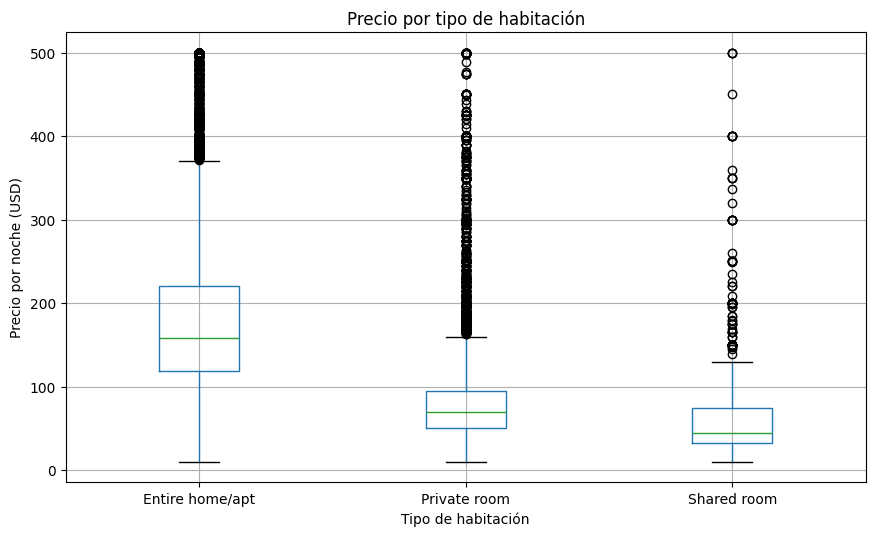

In [ ]:
datos_limpios.boxplot(column="price", by="room_type", figsize=(10, 6))
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio por noche (USD)")
plt.title("Precio por tipo de habitación")
plt.suptitle("")
plt.show()

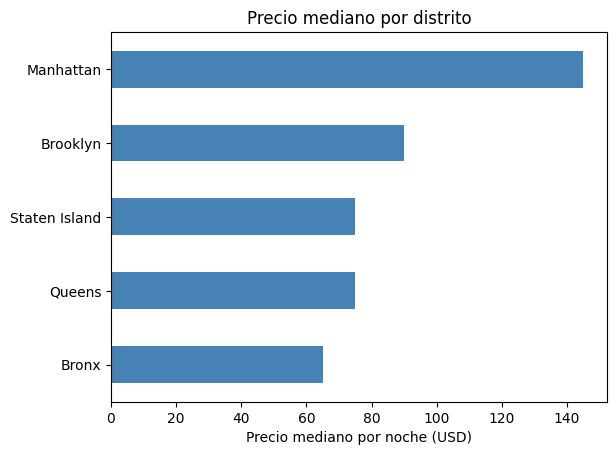

In [ ]:
datos_limpios.groupby("neighbourhood_group")["price"].median().sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Precio mediano por noche (USD)")
plt.ylabel("")
plt.title("Precio mediano por distrito")
plt.show()

In [ ]:
datos_limpios.corr(numeric_only=True)

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,0.586418,-0.004236,0.093493,0.010080,-0.015194,-0.320625,0.181193,0.132278,0.081625
host_id,0.586418,1.000000,0.018895,0.132880,0.008836,-0.019474,-0.138975,0.211858,0.151999,0.200594
latitude,-0.004236,0.018895,1.000000,0.086431,0.069670,0.024652,-0.014233,-0.017810,0.019554,-0.012869
longitude,0.093493,0.132880,0.086431,1.000000,-0.292096,-0.064373,0.057195,0.138152,-0.114992,0.090099
price,0.010080,0.008836,0.069670,-0.292096,1.000000,0.029189,-0.048237,-0.049534,0.163648,0.094630
minimum_nights,-0.015194,-0.019474,0.024652,-0.064373,0.029189,1.000000,-0.080062,-0.124842,0.129113,0.144368
number_of_reviews,-0.320625,-0.138975,-0.014233,0.057195,-0.048237,-0.080062,1.000000,0.589614,-0.072285,0.177573
reviews_per_month,0.181193,0.211858,-0.017810,0.138152,-0.049534,-0.124842,0.589614,1.000000,-0.047719,0.168563
calculated_host_listings_count,0.132278,0.151999,0.019554,-0.114992,0.163648,0.129113,-0.072285,-0.047719,1.000000,0.227636
availability_365,0.081625,0.200594,-0.012869,0.090099,0.094630,0.144368,0.177573,0.168563,0.227636,1.000000


In [ ]:
!pip install sweetviz
!pip install pygwalker
!pip install dtale
import dtale
import dtale.app as dtale_app
dtale_app.USE_COLAB = True
d = dtale.show(data)
d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB

/usr/local/lib/python3.13/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




https://40000-m-s-kkb-usw4c1-2em8vj74zperg-c.us-west4-1.prod.colab.dev/dtale/main/1